In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from pathlib import Path
from itertools import combinations

In [9]:
target_long_df = pd.read_parquet("rank1_target_contacts_long_5A.parquet")
binder_long_df = pd.read_parquet("rank1_binder_contacts_long_10A.parquet")
pair_long_df = pd.read_parquet("rank1_contact_pairs_long_5A.parquet")

In [10]:
df_csv = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results_old/AdaptyvBio/contest_2_round_2_metrics_summary.csv")

In [4]:
target_merged = target_long_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
target_merged = target_merged.drop(columns=["sequence"])

In [5]:
plot_target = target_merged[target_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

In [18]:
binder_merged = binder_long_df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
binder_merged = binder_merged.drop(columns=["sequence"])

In [19]:
plot_binder = binder_merged[binder_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()

In [30]:
# Create contact sets: (binder, method) → set of residues
contact_sets = (
    plot_binder
    .groupby(["binder_sequence", "method", "binding"])["binder_resseq"]
    .apply(lambda x: set(x.dropna()))
    .reset_index(name="contact_set")
)

rows = []

for binder, group in contact_sets.groupby("binder_sequence"):
    methods = group["method"].values
    sets = group["contact_set"].values
    
    # all rows in group have same Binding → just take first
    binding = group["binding"].iloc[0]
    
    for (m1, s1), (m2, s2) in combinations(zip(methods, sets), 2):
        if len(s1 | s2) == 0:
            jaccard = 0.0
        else:
            jaccard = len(s1 & s2) / len(s1 | s2)
        
        rows.append({
            "binder_sequence": binder,
            "method_1": m1,
            "method_2": m2,
            "jaccard": jaccard,
            "Binding": binding   # ← add it here
        })

jaccard_df = pd.DataFrame(rows)

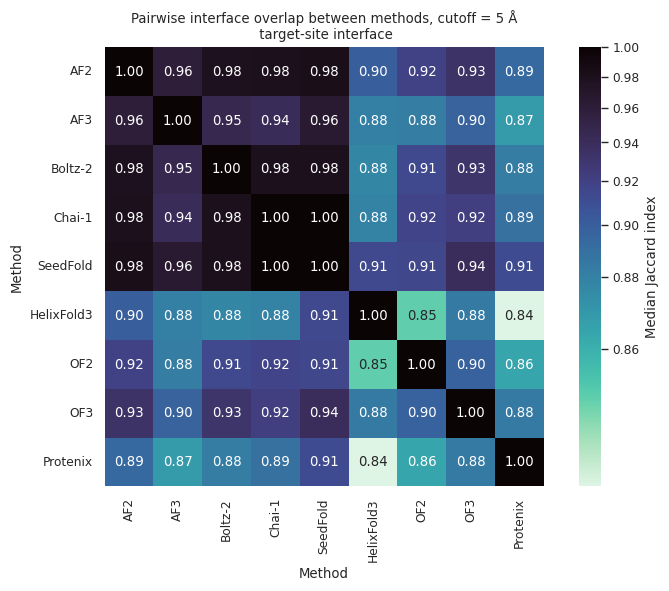

In [31]:
# Median Jaccard per method pair
jaccard_matrix = (
    jaccard_df
    .groupby(["method_1", "method_2"])["jaccard"]
    .median()
    .unstack()
)

# Make symmetric
jaccard_matrix = jaccard_matrix.combine_first(jaccard_matrix.T)

# Use one shared method order
method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]

jaccard_matrix = jaccard_matrix.reindex(
    index=method_order,
    columns=method_order
)

norm = colors.PowerNorm(gamma=0.5)


# Fill diagonal
for m in method_order:
    jaccard_matrix.loc[m, m] = 1.0

plt.figure(figsize=(8, 6))
sns.heatmap(
    jaccard_matrix,
    annot=True,
    fmt=".2f",
    cmap="mako_r",
    vmin=0.4,
    vmax=1,
    square=True,
    cbar_kws={"label": "Median Jaccard index"},
    norm=norm
)

plt.title("Pairwise interface overlap between methods, cutoff = 5 Å\n target-site interface")
plt.xlabel("Method")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

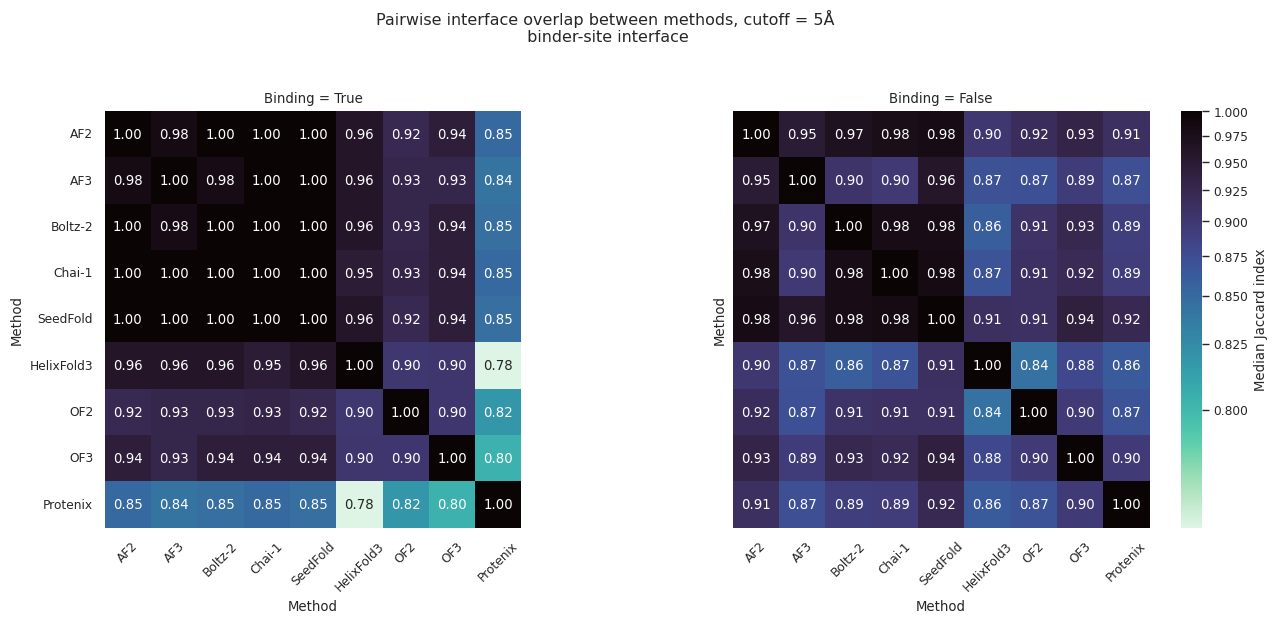

In [32]:
method_order = [
    "AF2", "AF3", "Boltz-2", "Chai-1",
    "SeedFold", "HelixFold3",
    "OF2", "OF3", "Protenix"
]
def make_jaccard_matrix(df):
    matrix = (
        df
        .groupby(["method_1", "method_2"])["jaccard"]
        .median()
        .unstack()
    )

    matrix = matrix.combine_first(matrix.T)
    matrix = matrix.reindex(index=method_order, columns=method_order)

    for m in method_order:
        matrix.loc[m, m] = 1.0

    return matrix


binding_matrix = make_jaccard_matrix(jaccard_df[jaccard_df["Binding"] == True])
nonbinding_matrix = make_jaccard_matrix(jaccard_df[jaccard_df["Binding"] == False])

norm = colors.PowerNorm(gamma=0.5)

sns.set_theme(style="white", context="paper")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.heatmap(
    binding_matrix,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    cmap="mako_r",   # ← reversed colormap
    vmin=0.4,
    vmax=1,
    square=True,
    cbar=False,
    norm=norm
)

sns.heatmap(
    nonbinding_matrix,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    cmap="mako_r",   # ← reversed here too
    vmin=0.4,
    vmax=1,
    square=True,
    cbar_kws={"label": "Median Jaccard index"},
    norm=norm
)

axes[0].set_title("Binding = True")
axes[1].set_title("Binding = False")

for ax in axes:
    ax.set_xlabel("Method")
    ax.set_ylabel("Method")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Pairwise interface overlap between methods, cutoff = 5Å\n binder-site interface", y=1.03)

plt.tight_layout()
plt.show()